# 02 - DDPM 训练 + 反向采样

> **01 我们学会了"怎么把图变成噪声"（前向，无需训练）。**
> **02 学反过来的：怎么从噪声一步步抠出一张图（反向，这才是要训练的部分）。**

**一句话直觉**：训练一个"祛噪神医"——给它一张带噪的图 $x_t$ 和当前时间步 $t$，让它猜出"这次加进去的噪声是什么样"。猜准了，反向走一千步就能从纯雪花生出猫。

---

**符号提醒**：$x_0$ / $x_t$ / $T$ / $\beta_t$ / $\alpha_t$ / $\bar\alpha_t$ / $\epsilon$ / $q$ 与 $p_\theta$ 忘了？回 01 课符号表。本课新增：

| 新符号 | 含义 |
|--------|------|
| $\epsilon_\theta(x_t, t)$ | 要训练的网络：输入带噪图和时间步，预测噪声 |
| $\sigma_t$ | 反向采样每步补回的噪声强度 |
| $z$ | 反向采样时新抽的标准高斯噪声 |
| $v$ | v-prediction 的预测目标（$\epsilon$ 和 $-x_0$ 的加权混合） |

---

**这个 notebook 的 KPI**：
- 理解 **为什么** DDPM 学的是噪声 $\epsilon$ 而不是原图 $x_0$
- 记住三个等价预测目标：$\epsilon$-pred / $x_0$-pred / v-pred
- 能默写训练 loss 和采样循环（**面试必考**）

## 核心 motivation：预测噪声 vs 预测原图

一个天然的想法：既然要去噪，那直接训练网络预测**原图 $x_0$** 不就行了吗？

**能做，但不优**。来看三个等价目标的区别：

| 目标 | 公式 | 什么时候好？ | 换算关系 |
|------|------|-------------|----------|
| **$\epsilon$-prediction** | 预测加进去的噪声 $\epsilon$ | $t$ 大时（噪声多）→ 好学 | 基准 |
| **$x_0$-prediction** | 直接预测原图 | $t$ 小时（噪声少）→ 好学 | $\hat x_0 = (x_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon)/\sqrt{\bar\alpha_t}$ |
| **v-prediction** | 预测两者的混合（Progressive Distillation，Salimans 2022） | 全 $t$ 范围都稳 | $v = \sqrt{\bar\alpha_t}\,\epsilon - \sqrt{1-\bar\alpha_t}\,x_0$ |

三者**线性可互换**（知道其中一个 + $x_t$ 就能算出另外两个），05 课会统一收口。

**为什么 DDPM 原版选 $\epsilon$-pred？**

- $t$ 大时，$x_t$ 几乎是纯噪声，让你"猜原图"相当于无中生有（梯度方差巨大）
- 但让你"猜噪声"就简单——因为大部分内容就是噪声
- **loss scale 天然均匀** → 训练稳

**v-prediction 越来越常见（SD2.1-768 / Imagen Video / Progressive Distillation 都用；注意 SDXL 仍是 $\epsilon$-pred；SD3/FLUX 是 rectified flow 的速度场，另一个概念，别混）**：
- $v = \sqrt{\bar\alpha_t}\epsilon - \sqrt{1-\bar\alpha_t}x_0$

> 📖 读式子：$v$ 是 $\epsilon$ 和 $-x_0$ 的加权混合。极端检查：$t \to 0$（噪声少）时 $\bar\alpha_t \to 1$，$v \to \epsilon$；$t \to T$（噪声多）时 $\bar\alpha_t \to 0$，$v \to -x_0$。**噪声少就预测噪声，噪声多就预测（负的）原图——哪个信息量大就预测哪个**，所以两端都稳。

**📝 面试高频题**：三种预测目标的区别是什么？答不出来基本没戏。

## DDPM 训练算法（一页纸）

**核心 loss**（原始 DDPM，Ho et al. 2020）：

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{x_0, t, \epsilon}\big[\|\epsilon - \epsilon_\theta(x_t, t)\|^2\big]$$

其中 $x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\,\epsilon$（01 学过的重参数化）。

**训练流程**（背下来，面试必考）：

```
for each batch x_0:
    t ~ Uniform{1, ..., T}        # 每个样本随机一个时间步
    eps ~ N(0, I)                  # 采噪声
    x_t = sqrt(alpha_bar[t])·x_0 + sqrt(1-alpha_bar[t])·eps  # 一步加噪
    pred = model(x_t, t)           # 网络预测
    loss = MSE(pred, eps)          # 简单回归损失
    backward + step
```

**就这么简单**。没有 GAN 的博弈、没有 VAE 的 KL 平衡、没有 PixelCNN 的串行，**单个 MSE loss，稳如狗**。

这就是 Diffusion 能取代 GAN 的根本原因：**把一个困难的分布学习问题，降级成了一个简单的逐像素回归**。

## 反向采样（DDPM 原版，随机版）

训练完了怎么生图？从纯噪声 $x_T \sim \mathcal{N}(0, I)$ 出发，反向走 T 步。

**每一步的更新公式**——这个公式不是拍脑袋：它是把贝叶斯公式套在 $q(x_{t-1}|x_t, x_0)$ 上、再把未知的 $x_0$ 用 $\epsilon$-预测反解代入后化简的结果。推导放折叠里；主线你只需要会**读**它。

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta(x_t, t)\right) + \sigma_t z, \quad z \sim \mathcal{N}(0, I)$$

> 📖 读式子，三段拆开：
> 1. $x_t - \frac{1-\alpha_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta$：从当前图里**减掉一小份预测噪声**——系数 $\ll 1$，一次只敢减一点
> 2. 除以 $\sqrt{\alpha_t}$：把前向缩小的信号**拉伸回来**
> 3. $+\,\sigma_t z$：**重新补一点随机性**（原版 DDPM 的"随机性"来源，03 课会把它拧成 0）
>
> 极端检查：模型完美且 $\beta_t \to 0$ 时退化为 $x_{t-1} \approx x_t$，每步只微调 ✓

<details><summary>完整后验推导（选读，面试要手推的展开看）</summary>

**目标**：求 $q(x_{t-1}|x_t, x_0)$（知道原图时，反向一步的真实分布）。

**Step 1 贝叶斯**：

$$q(x_{t-1}|x_t, x_0) \propto q(x_t|x_{t-1})\, q(x_{t-1}|x_0)$$

（用了前向的马尔可夫性：$q(x_t|x_{t-1}, x_0) = q(x_t|x_{t-1})$）

**Step 2 两个高斯相乘、对指数配方**。已知

$$q(x_t|x_{t-1}) = \mathcal{N}(\sqrt{\alpha_t}\,x_{t-1},\ \beta_t I), \qquad q(x_{t-1}|x_0) = \mathcal{N}(\sqrt{\bar\alpha_{t-1}}\,x_0,\ (1-\bar\alpha_{t-1}) I)$$

对 $x_{t-1}$ 配平方，得到仍是高斯：

$$q(x_{t-1}|x_t, x_0) = \mathcal{N}(\tilde\mu_t(x_t, x_0),\ \tilde\beta_t I)$$

$$\tilde\mu_t = \frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}\,x_0 + \frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\,x_t, \qquad \tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\,\beta_t$$

**Step 3 代入 $x_0$ 的估计**。采样时不知道真 $x_0$，用 $\epsilon$-预测反解：

$$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t, t)}{\sqrt{\bar\alpha_t}}$$

代入 $\tilde\mu_t$ 化简（注意 $1-\alpha_t = \beta_t$、$\bar\alpha_t = \alpha_t\bar\alpha_{t-1}$），就得到正文的更新公式：

$$\mu_\theta = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\epsilon_\theta\right)$$

采样时取 $\sigma_t^2 = \tilde\beta_t$（或简化成 $\beta_t$，Ho 2020 两种都试过，效果接近）。
</details>

**为什么要加扰动？** 因为 DDPM 把反向过程建模成一个**随机过程（SDE）**。每一步都加点扰动，最后能覆盖整个数据分布。坏处：要走很多步（1000 步）才能收敛。

**📝 面试高频**：DDPM 推理为什么慢？答：DDPM 反向核是高斯，这个**高斯近似只在小步长下成立**——步子一大，真实的反向条件分布不再近似高斯，质量掉得快（DDPM 也能 respacing 跳步，iDDPM 就这么干，只是掉质量比 DDIM 快）。DDIM 走确定性 ODE，数值积分天然允许大步长。**03 DDIM 就是来解决这个的**。

## 代码手撕（只撕核心三件套）

按"理解优先，代码精简"原则，我们只撕面试必考的三块：

1. **最小 UNet**（够用就行，真正 SOTA 看 SD 源码）
2. **训练 loop**（重点：`t` 的采样 + $\epsilon$-pred loss）
3. **DDPM 采样 loop**（重点：反向 Markov 链）

数据用合成"7"字图（01 同款，不依赖下载）。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


### 数据：合成"7"字（16×16，CPU 友好）

面试时不会考数据处理，这里一笔带过。

Training data: torch.Size([512, 1, 16, 16]), range [-1.22, 1.18]


/tmp/ipykernel_3517764/320769161.py:27: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3517764/320769161.py:27: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3517764/320769161.py:27: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3517764/320769161.py:27: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3517764/320769161.py:27: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3517764/320769161.py:27: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3517764/320769161.py:27: UserWarning: Glyph 25104 (\N{CJK UNIFIED I

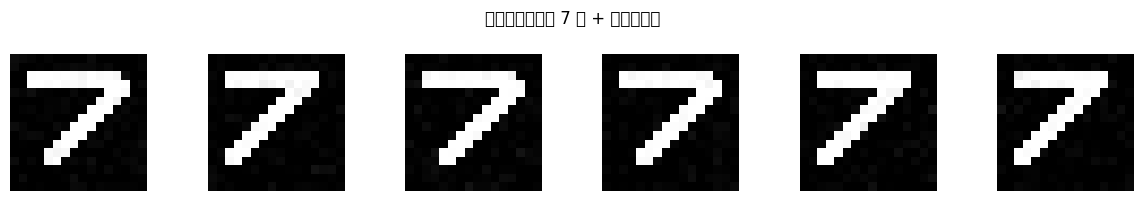

In [2]:
def make_seven(n=256, size=16):
    """生成 n 张带噪声扰动的 '7' 字图，范围 [-1, 1]"""
    imgs = []
    for _ in range(n):
        img = -torch.ones(size, size)  # 背景黑 (-1)
        # 横笔
        img[2:4, 2:13] = 1.0
        # 斜笔（随机抖动一下，增加多样性）
        offset = np.random.randint(-1, 2)
        for i, col in enumerate(range(12+offset, 3+offset, -1)):
            row = 3 + i * (size-5) // 10
            if 0 <= row < size and 0 <= col < size:
                img[row:row+2, col-1:col+1] = 1.0
        # 加微小扰动
        img += torch.randn_like(img) * 0.05
        imgs.append(img)
    return torch.stack(imgs).unsqueeze(1)  # [N, 1, 16, 16]

x_train = make_seven(512)
print(f'Training data: {x_train.shape}, range [{x_train.min():.2f}, {x_train.max():.2f}]')

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i, 0], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')
plt.suptitle('训练数据（合成 7 字 + 轻微抖动）')
plt.tight_layout()
plt.show()

### 最小 UNet（理解结构即可，不要抠细节）

真实 Diffusion 的 UNet 有 ResBlock / Attention / GroupNorm / time embedding / skip connection 一套。这里**只撕面试必考的时间嵌入**，其他用 MLP 近似。

**面试必答：时间步 $t$ 怎么输入网络？**

答：用**正弦位置编码**把标量 $t$ 变成高维向量，再过 MLP，加到每个特征图上（类似 Transformer 的位置编码）。**不要直接把 $t$ 当 scalar 喂进去**——低维标量条件很难让网络学到对 $t$ 的高频依赖。

In [5]:
class SinusoidalTimeEmbed(nn.Module):
    """把标量 t 变成 dim 维向量。这是面试必考点。"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: [B] -> [B, dim]
        half = self.dim // 2
        freqs = torch.exp(-np.log(10000) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class TinyDenoiser(nn.Module):
    """极简去噪器：MLP + 时间嵌入。真正 SOTA 用 UNet，但面试考的是'怎么注入 t'。"""
    def __init__(self, img_size=16, hidden=256, t_dim=64):
        super().__init__()
        self.img_size = img_size
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(t_dim),
            nn.Linear(t_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )
        self.net = nn.Sequential(
            nn.Linear(img_size * img_size, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, img_size * img_size),
        )

    def forward(self, x, t):
        # x: [B, 1, H, W], t: [B]
        B = x.size(0)
        h = x.view(B, -1)
        t_emb = self.time_embed(t)  # [B, hidden]
        # 简化：把 t_emb 直接加到第一层输出上
        h = self.net[0](h)
        h = h + t_emb
        for layer in self.net[1:]:
            h = layer(h)
        return h.view(B, 1, self.img_size, self.img_size)

model = TinyDenoiser().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Params: {n_params/1e6:.2f}M')

Params: 0.35M


### Noise schedule 预计算（复用 01 的 linear schedule）

In [6]:
T = 200  # 真实 DDPM 是 1000，我们为了快用 200
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1. - betas
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1 - alpha_bars)

print(f'T={T}, alpha_bar[0]={alpha_bars[0]:.4f}, alpha_bar[T-1]={alpha_bars[-1]:.6f}')

T=200, alpha_bar[0]=0.9999, alpha_bar[T-1]=0.132183


### 训练 loop（**面试必默写代码**）

把下面这段背下来，面试能手写就是 diffusion 入门过关。

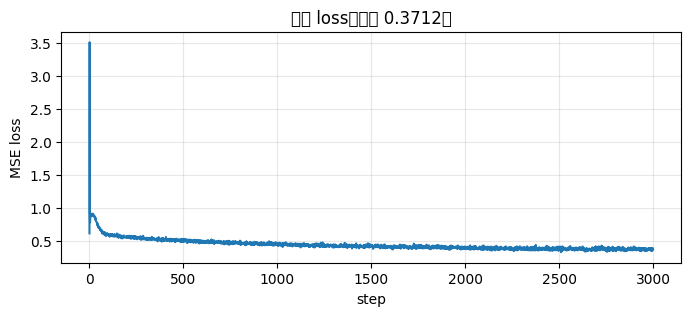

In [ ]:
def train_step(model, x0, T, sqrt_ab, sqrt_1mab):
    B = x0.size(0)
    t = torch.randint(0, T, (B,), device=x0.device)           # 1. 随机时间步
    eps = torch.randn_like(x0)                                 # 2. 采噪声
    xt = sqrt_ab[t, None, None, None] * x0 + \
         sqrt_1mab[t, None, None, None] * eps                  # 3. 一步加噪
    eps_pred = model(xt, t)                                    # 4. 预测噪声
    loss = F.mse_loss(eps_pred, eps)                           # 5. MSE
    return loss

x_train = x_train.to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

losses = []
n_steps = 300   # 每步随机抽一个 batch（不是完整遍历数据集的 epoch）
batch_size = 128
for step in range(n_steps):
    idx = torch.randperm(x_train.size(0))[:batch_size]
    x0 = x_train[idx]
    loss = train_step(model, x0, T, sqrt_alpha_bars, sqrt_one_minus_alpha_bars)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.xlabel('step'); plt.ylabel('MSE loss'); plt.title(f'训练 loss（最终 {losses[-1]:.4f}）')
plt.grid(alpha=0.3); plt.show()

### DDPM 反向采样（**面试必默写代码**）

注意 `z` 的条件：`t > 0` 时才加随机项，`t == 0` 直接返回均值（最后一步不加噪）。这是个常见的 bug 源。

Font 'default' does not have a glyph for '\uff08' [U+ff08], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u7eaf' [U+7eaf], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u566a' [U+566a], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u58f0' [U+58f0], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\uff09' [U+ff09], substituting with a dummy symbol.
/tmp/ipykernel_3517764/1988687350.py:38: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3517764/1988687350.py:38: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3517764/1988687350.py:38: UserWarning: Glyph 37319 (\N{CJK UNIFIED IDEOGRAPH-91C7}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3517764/198868735

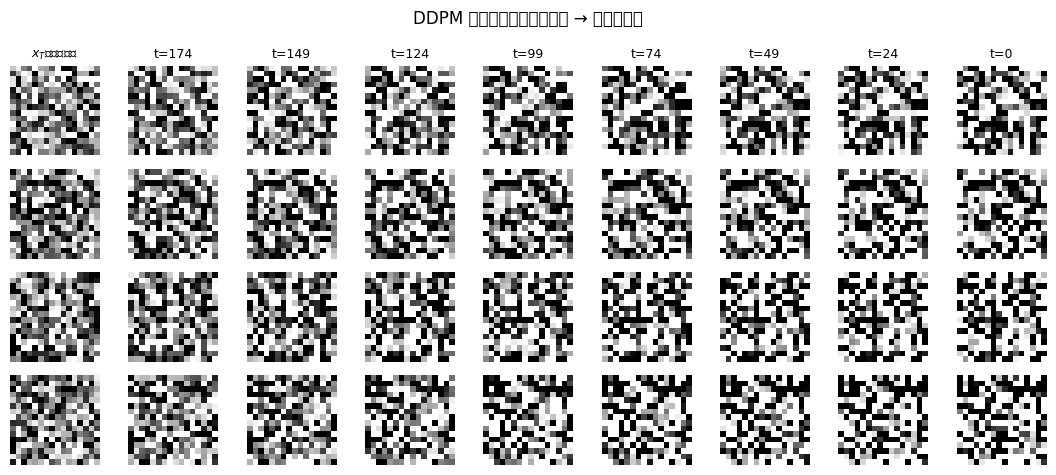

In [12]:
@torch.no_grad()
def ddpm_sample(model, n, T, betas, alphas, alpha_bars, img_size=16, device='cpu'):
    model.eval()
    x = torch.randn(n, 1, img_size, img_size, device=device)   # x_T ~ N(0, I)
    traj = [x.clone()]
    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch)
        # 核心更新公式
        coef = (1 - alphas[t]) / torch.sqrt(1 - alpha_bars[t])
        mean = (x - coef * eps_pred) / torch.sqrt(alphas[t])
        if t > 0:
            sigma = torch.sqrt(betas[t])
            x = mean + sigma * torch.randn_like(x)
        else:
            x = mean
        if t % (T // 8) == 0:
            traj.append(x.clone())
    model.train()
    return x, traj

samples, traj = ddpm_sample(model, 8, T, betas, alphas, alpha_bars, device=device)

# 可视化：每行一个样本，从噪声到图
fig, axes = plt.subplots(4, len(traj), figsize=(len(traj)*1.2, 4.8))
for row in range(4):
    for col, xt in enumerate(traj):
        axes[row, col].imshow(xt[row, 0].cpu(), cmap='gray', vmin=-1, vmax=1)
        axes[row, col].axis('off')
        if row == 0:
            # traj[0] 是初始纯噪声 x_T；之后每个元素是在 t 整除 T//8 的那步更新后存的 x_{t-1}
            if col == 0:
                axes[row, col].set_title('$x_T$（纯噪声）', fontsize=9)
            else:
                step = T - col * (T // 8)
                axes[row, col].set_title(f't={max(step-1,0)}', fontsize=9)
plt.suptitle('DDPM 反向采样轨迹（纯噪声 → 逐步成形）')
plt.tight_layout(); plt.show()

**看图直觉**：

- 最左列是纯随机噪声（$x_T$）
- 每往右一列就走了 $T/8$ 步去噪
- 最右列（$x_0$）应该能看出 "7" 字的大致形状

如果形状不明显，是因为：(1) 模型太小 (2) 训练步数太少 (3) 合成数据太简单信息量低。**这个 notebook 的目的不是炫生成效果，是把循环跑通、把流程理解透**。

## 工程彩蛋：DDPM 训练的几个坑

这些坑面试时问到能加分：

1. **EMA 权重**：真实训练里 sampling 时用 EMA 版本的 model 权重（decay=0.9999），比 raw weights 效果好一大截。SD、Imagen 都这么做。
2. **loss weighting**：$\mathcal{L}_\text{simple}$ 其实砍掉了 ELBO 里的 $\frac{\beta_t^2}{2\sigma_t^2\alpha_t(1-\bar\alpha_t)}$ 权重项（Ho 2020 Eq.12）——这个简化反而效果更好。**面试官问"DDPM 的 loss 是 ELBO 吗"**，答"不是，是 ELBO 的简化版本，但工程上更好用"。
3. **min-SNR weighting（Hang 2023）**：按 SNR 截断做 loss 加权，训练收敛更快。社区训练常用。
4. **时间步采样**：一般均匀采样 $t \sim \text{Uniform}\{0, T-1\}$，但 SD3 / FLUX 用 **logit-normal** 采样（t 更密集在中间），收敛更好。

## 面试题连问

### Q1: DDPM 训练 loss 是什么？为什么预测 $\epsilon$ 而不是 $x_0$？

<details><summary>参考答案</summary>

Loss：$\mathcal{L} = \mathbb{E}_{x_0, t, \epsilon}\|\epsilon - \epsilon_\theta(x_t, t)\|^2$，简单的 MSE。

预测 $\epsilon$ 的好处：
- $t$ 大时数据基本是噪声，"猜噪声"天然简单；"猜原图"方差巨大
- loss scale 在各 $t$ 下均匀 → 训练稳
- 是 ELBO 推导的自然形式（简化后的）

**进阶**：v-prediction 越来越常见（SD2.1-768 / Imagen Video / Progressive Distillation），在 $t$ 小和 $t$ 大时都稳，是 $\epsilon$-pred 的升级版。注意 SDXL 仍是 $\epsilon$-pred；SD3/FLUX 是 rectified flow 速度场（另一个概念）。
</details>

---

### Q2: $\epsilon$-prediction / $x_0$-prediction / v-prediction 三者区别？

<details><summary>参考答案</summary>

三者本质等价（互相可换算），但训练动态不一样：

| 预测目标 | 适合区间 | 代表方法 |
|----------|----------|----------|
| $\epsilon$ | t 大时好（噪声多） | DDPM 原版 |
| $x_0$ | t 小时好（噪声少） | 早期工作 |
| v = $\sqrt{\bar\alpha_t}\epsilon - \sqrt{1-\bar\alpha_t}x_0$ | 全 t 范围稳 | SD2.1-768 / Imagen Video / Progressive Distillation |

v-pred 越来越常见，因为在 $t$ 两端都不崩。

**注意区分两个维度**：这张表说的"适合区间"是**好学**（预测目标在该区间信息量大、可辨识）；05 课 Q4 会讲另一个维度——**换算数值稳定性**（从预测目标反解 $\hat x_0$ / $\hat\epsilon$ 时会不会除以近零数）。两者是两回事，面试别混。
</details>

---

### Q3: DDPM 反向采样每一步为什么要加随机项 $\sigma_t z$？不加会怎样？

<details><summary>参考答案</summary>

DDPM 把反向过程建模为**随机过程（SDE）**，每步噪声来自后验 $q(x_{t-1}|x_t, x_0)$ 的方差。加随机项保证模型能覆盖完整的数据分布。

**不加随机项 = DDIM**。DDIM 推断等价于求解一个**确定性 ODE**，样本变成轨迹的函数，同一噪声输入得到同一张图。好处：可跳步加速、图像编辑（inversion）。这是 03 的主题。
</details>

---

### Q4: 为什么 DDPM 推理要 1000 步？能不能减少？

<details><summary>参考答案</summary>

DDPM 的 1000 步来自它对反向核的**高斯假设**——真实的反向条件分布只在小步长下才近似高斯，所以每步只能走一小段。DDPM 其实也能 respacing 跳步（iDDPM 就这么做），只是步子越大高斯近似越差、质量掉得越快。DDIM 走确定性 ODE，数值积分允许大步长，掉质量慢得多。

减少步数的路径（按时间线）：
1. **DDIM (2020)**：确定性 ODE，50 步能出图
2. **DPM-Solver (2022)**：高阶 ODE 求解器，10-20 步
3. **Consistency Models (2023)** / **LCM (2023)**：1-4 步
4. **DMD/DMD2 (2023-2024)**：分布蒸馏，1 步接近教师质量
5. **Flow Matching (SD3/FLUX, 2024)**：从训练范式就用 ODE，4-28 步即可

这是整个领域从 2020→2025 的主线。
</details>

---

### Q5: 时间步 $t$ 怎么输入网络？为什么不能直接当 scalar 喂？

<details><summary>参考答案</summary>

用**正弦位置编码**（sin/cos 多频率）把 $t$ 映射到高维，再过 MLP，然后注入每个 ResBlock（加法或 FiLM 缩放偏移）。

直接当 scalar 喂的话，低维标量条件很难让网络学到对 $t$ 的**高频依赖**（NTK 视角：普通 MLP 对低维输入有谱偏置，偏向低频光滑函数）；而 noise schedule 下不同 $t$ 的数据分布差异非常大（$x_t$ 从几乎纯图到几乎纯噪声），需要对 $t$ 敏感的时间感知。Fourier 特征（正弦位置编码）把 $t$ 展开成多频率的傅立叶基，正好解决这个。

这个技巧直接借鉴自 Transformer 位置编码。
</details>

---

### Q6: DDPM / DDIM / Flow Matching 的关系是什么？

<details><summary>参考答案</summary>

三者本质都是 **"学一个从噪声到数据的映射"**，区别在建模视角：

| 方法 | 建模 | 采样 | 关系 |
|------|------|------|------|
| DDPM | 随机过程 (SDE) | 1000 步，每步随机 | 原始形式 |
| DDIM | 确定性 ODE | 50 步，确定性 | DDPM 的 ODE 极限（$\eta=0$）|
| Flow Matching | 直接学 ODE 速度场 | 4-28 步 | 不再需要"加噪-去噪"视角，直接学"运输" |

**演进逻辑**：从"随机漫步回家"→"沿轨迹滑下来"→"直线狂奔"。每一步都在缩短推理路径。
</details>

---

### 🎯 加分题：为什么真实训练要用 EMA 权重做 sampling？

<details><summary>参考答案</summary>

Raw weights 在训练后期会在 loss 局部抖动（noise 来自 batch、dropout 等），直接用会让生成带噪。**EMA**：

$$\theta_\text{EMA} \leftarrow 0.9999 \cdot \theta_\text{EMA} + 0.0001 \cdot \theta$$

低通滤波，等价于"轨迹上的平均权重"。FID 通常有可观改善，SD/Imagen/FLUX 全部开启。
</details>